# Notebook for work on development of un-spot-able

## Setting up needed imports & data

### Imports from create_eigens

In [1]:
#General imports
import os
import sys
import numpy as np
import faulthandler
faulthandler.enable()

# Directory structure
from pathlib import Path
maindir = str(Path(os.getcwd()).parent)
libdir  = os.path.join(maindir, 'lib')
if not libdir in sys.path:
    sys.path.append(maindir)
    sys.path.append(libdir)

from lib import eigen
from lib import utils
from lib import fitclass as fc
from lib.spotable import spotable as se


import starry2 as starry
# Set up starry configuration
starry.config.quiet = True
starry.config.lazy = True
sys.setrecursionlimit(10000) # starry seems to have a lot of recursion


# Whether or not to show print statements in code
dpm = True #change to False to make quiet

### Additional imports from create_emaps

In [2]:
#General imports 
from cmcrameri import cm
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt


#lib imports
from lib import lat_lon_lines
from lib import pca

### Additional imports from create_rv & create_real_null

In [3]:
#General imports
try:
    plt.rcParams['animation.convert_path'] = '/opt/homebrew/bin/magick'
    pass
except:
    pass

import matplotlib.animation as animation
from IPython.display import HTML

### Importing each .py file

In [4]:
import create_eigens
import create_emaps
import create_rv
import create_real_null

### Reading Config File

In [5]:
fit = fc.Fit()
fit.read_config("../eridani.cfg")

cfg = fit.cfg

lmax = cfg.sim.lmax
udeg = cfg.star.udeg

### Python magic commands for better notebook displays

In [6]:
%matplotlib inline

## More Plot Tests - July 7th

In [7]:
print("hi")

hi


In [8]:
base_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-eigens/eigeny.txt")
norm_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

s1 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
s2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [9]:
s1.map[:,:] = base_eigens[16]
s2.map[:,:] = norm_eigens[1]

In [10]:
# create_rv.flux_rv_line(s2, theta = np.linspace(-180, 180, 91), flux=None, rv=None, #works
#                  flux_name=None,rv_name=None, #works
#                  flux_only=False,rv_only=False, transparent=True,  #works
#                  labels=True, title = "Hi", border=True, ticks=True, 
#                  centerline=True, fontsize=10, color="sandybrown", cline_color="k")

In [11]:
# create_rv.multi_phase_plot(s2,fname=None, cmap=cm.buda, norm=None)

In [12]:
s2.map[0,0] = 3

In [23]:
create_rv.map_animations(s1,theta = np.linspace(0, 360, 46)[:-1], fname=None, cmap = cm.bam,
                   maps_only = False, flux_only = False, rv_only = False, color="sandybrown",
                   fontsize=16, map_labels=True, norm=mpl.colors.CenteredNorm(),


                   interval = 75, fps = 10,  #need to check these!
                   
                
                   colorbar="bottom", colorbar_label=True, transparent=False, marker_color = "darkgrey",
                   curve_border=True, curve_labels=True, ticks=True, legend=False, curve_gridlines=False,
                   centerline=True, cline_color="k",guideline=True, guideline_color="k", 


                   dpi=100, html5_video=True)

In [14]:
# create_emaps.create_eflux(s1, base_eigens, emaps_path="../dev_materials", other_fname="hi.png",
#                  theta = np.linspace(-180, 180, 361),
#                  transparent=False, fontsize=10, centerline=True,
#                  labels=False, title = "hi", border=False, ticks=False, cline_color="blue",
#                  individual=False, color="red", dpi=100)

In [15]:
assert True == False

AssertionError: 

## Limb Darkening Test (2) - July 1st

In [ ]:
base_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-eigens/eigeny.txt")
norm_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

limb1 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
limb2 = utils.initstar(fit, lmax, udeg=udeg + [.5] + [.3], include_rv=True)

In [ ]:
limb1.map[:,:] = base_eigens[20]
limb2.map[:,:] = base_eigens[20]

In [ ]:
limb1.map.show(theta=np.linspace(0,361,91),rv=False,dpi=100,colorbar=True)
limb2.map.show(theta=np.linspace(0,361,91),rv=False,dpi=100,colorbar=True)

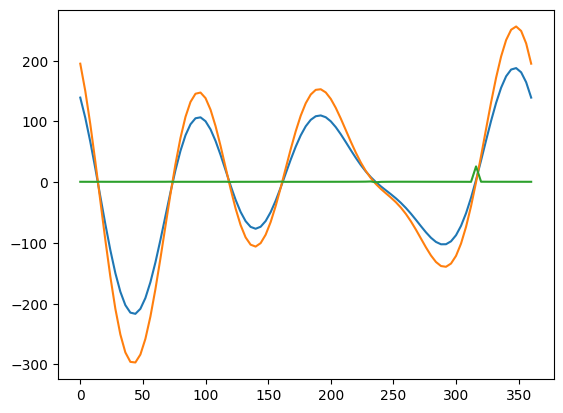

: 

In [ ]:
plt.plot(np.linspace(0,360,91),limb1.map.rv(theta=np.linspace(0,360,91)).eval())
plt.plot(np.linspace(0,360,91),limb2.map.rv(theta=np.linspace(0,360,91)).eval())
plt.plot(np.linspace(0,360,91),limb1.map.rv(theta=np.linspace(0,360,91)).eval() / limb2.map.rv(theta=np.linspace(0,360,91)).eval())

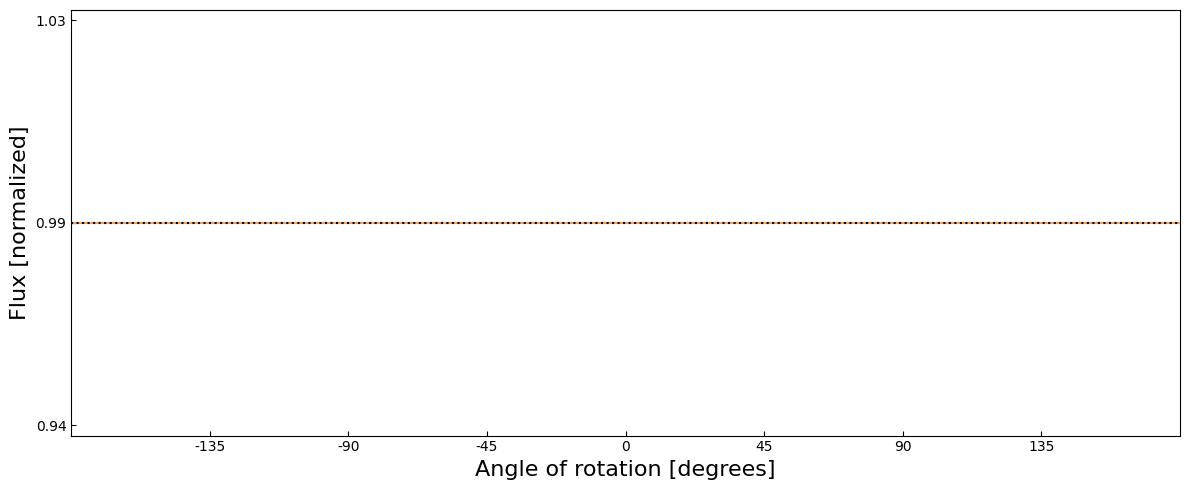

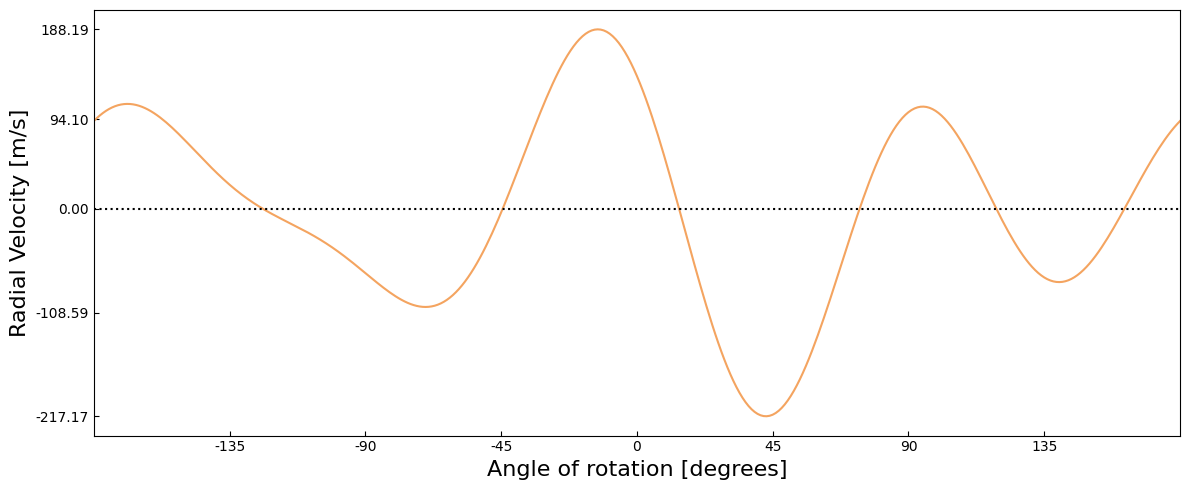

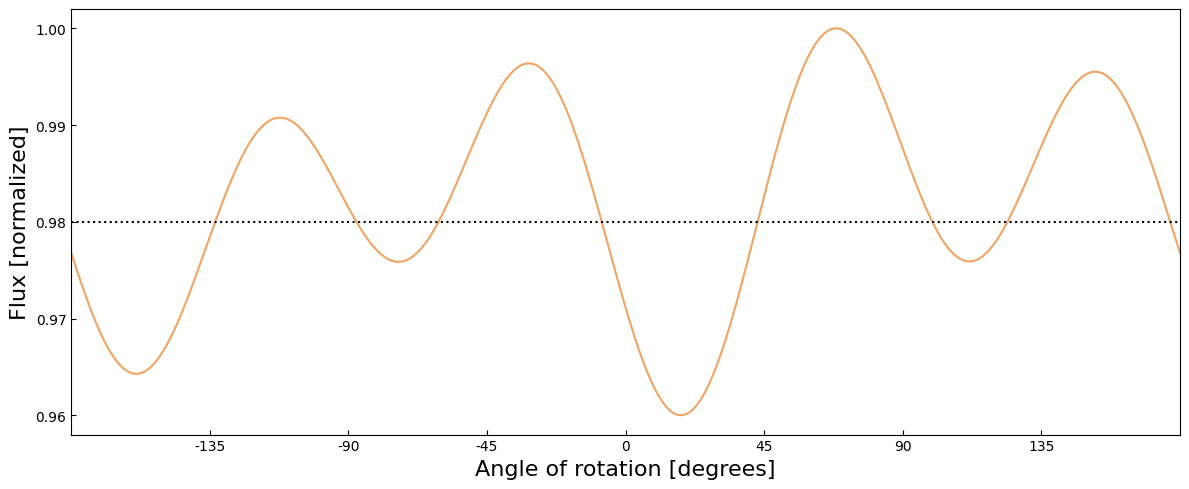

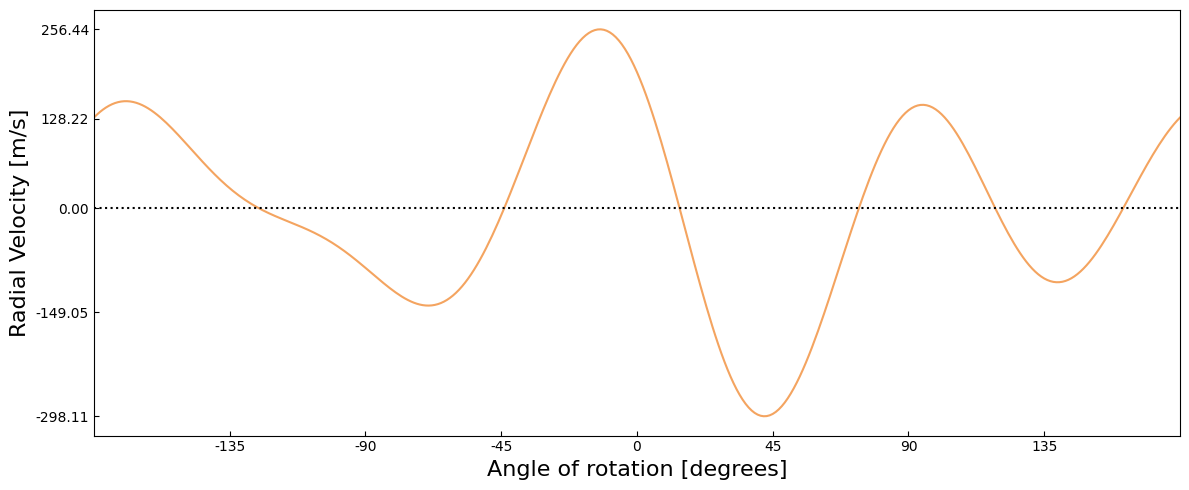

In [ ]:
create_rv.flux_rv_line(limb1)
create_rv.flux_rv_line(limb2)

## Limb Darkening Test - June 30th

In [ ]:
base_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-eigens/eigeny.txt")
norm_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

limb = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
no_limb = utils.initstar(fit, lmax, udeg=[], include_rv=True)

In [ ]:
limb.map[:,:] = base_eigens[20]
no_limb.map[:,:] = base_eigens[20]

limb.map[0,0] = 3
no_limb.map[0,0] = 3

In [ ]:
realistic_star, inv_realistic_star, uni_star_limb, uni_star, ratio_no_limb = create_real_null.set_up_stars(fit, np.ones(lmax), uni_comp=1)

In [ ]:
# limb.map.add_spot(-0.1, sigma=0.03, lat=0, lon=0)

In [ ]:
limb.map.inc = 0
no_limb.map.inc = limb.map.inc

inc = limb.map.inc.eval()

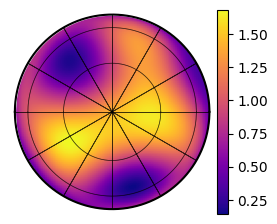

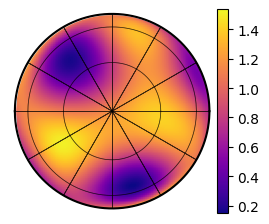

In [ ]:
limb.map.show(rv=False,colorbar=True)
no_limb.map.show(rv=False,colorbar=True)

In [ ]:
print(limb.map.intensity(lon=0,lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=0,lat=0,rv=False).eval() * 1.2168164026851083)
print()
print(limb.map.intensity(lon=-90,lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=-90,lat=0,rv=False).eval() * 1.2168164026851083)
print()
print(limb.map.intensity(lon=np.linspace(-180,180,91),lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=np.linspace(-180,180,91),lat=0,rv=False).eval() * 1.2168164026851083)

[1.51984787]
[1.51984787]

[0.40801522]
[1.1078339]

[-0.77442553 -0.83681649 -0.89076961 -0.93177997 -0.95591996 -0.96024622
 -0.94309774 -0.90425134 -0.84491923 -0.76759416 -0.67576643 -0.57355258
 -0.4652849  -0.35511338 -0.2466674  -0.14281347 -0.04553072  0.0440918
  0.12574834  0.1997271   0.26667442  0.32735276  0.3824308   0.4323365
  0.47719251  0.51684006  0.5509431   0.57915281  0.6013035   0.61760674
  0.62881081  0.63629738  0.64209589  0.64880692  0.65943734  0.67716139
  0.70503065  0.74566234  0.80093825  0.87174576  0.95778891  1.05749067
  1.16799961  1.28530449  1.40445129  1.51984787  1.62563419  1.71608996
  1.78604773  1.8312781   1.84881478  1.83719102  1.79656485  1.7287194
  1.63693433  1.52573571  1.40054323  1.26724354  1.13172713  0.99943101
  0.87493063  0.7616207   0.66151682  0.57519771  0.50189292  0.43970499
  0.38593953  0.33750385  0.29132646  0.24474679  0.19582817  0.14355638
  0.08790109  0.02973498 -0.02937548 -0.08747646 -0.14258567 -0.19305185
 

In [ ]:
limb.map.inc = 90
no_limb.map.inc = limb.map.inc

inc = limb.map.inc.eval()

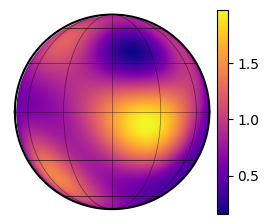

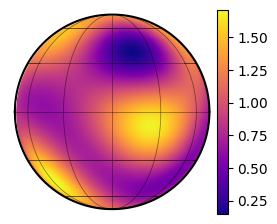

In [ ]:
limb.map.show(rv=False,colorbar=True)
no_limb.map.show(rv=False,colorbar=True)

In [ ]:
print(limb.map.intensity(lon=0,lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=0,lat=0,rv=False).eval() * 1.2168164026851083)
print()
print(limb.map.intensity(lon=-90,lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=-90,lat=0,rv=False).eval() * 1.2168164026851083)
print()
print(limb.map.intensity(lon=np.linspace(-180,180,91),lat=0,rv=False).eval())
print(no_limb.map.intensity(lon=np.linspace(-180,180,91),lat=0,rv=False).eval() * 1.2168164026851083)


[1.51984787]
[1.51984787]

[0.40801522]
[1.1078339]

[-0.77442553 -0.83681649 -0.89076961 -0.93177997 -0.95591996 -0.96024622
 -0.94309774 -0.90425134 -0.84491923 -0.76759416 -0.67576643 -0.57355258
 -0.4652849  -0.35511338 -0.2466674  -0.14281347 -0.04553072  0.0440918
  0.12574834  0.1997271   0.26667442  0.32735276  0.3824308   0.4323365
  0.47719251  0.51684006  0.5509431   0.57915281  0.6013035   0.61760674
  0.62881081  0.63629738  0.64209589  0.64880692  0.65943734  0.67716139
  0.70503065  0.74566234  0.80093825  0.87174576  0.95778891  1.05749067
  1.16799961  1.28530449  1.40445129  1.51984787  1.62563419  1.71608996
  1.78604773  1.8312781   1.84881478  1.83719102  1.79656485  1.7287194
  1.63693433  1.52573571  1.40054323  1.26724354  1.13172713  0.99943101
  0.87493063  0.7616207   0.66151682  0.57519771  0.50189292  0.43970499
  0.38593953  0.33750385  0.29132646  0.24474679  0.19582817  0.14355638
  0.08790109  0.02973498 -0.02937548 -0.08747646 -0.14258567 -0.19305185
 

In [ ]:
limb.map.inc = 70
no_limb.map.inc = limb.map.inc

inc = 90#limb.map.inc.eval()

i = 20

theta = np.linspace(-90,90,46)

mu = np.sin(inc*np.pi/180) * np.cos(i * np.pi/180) * np.cos(theta *np.pi/180) + np.cos(inc*np.pi/180) * np.sin(i * np.pi/180)
# print(mu)

limb_law = 1 - udeg[0]*(1-mu) - udeg[1]*(1-mu)**2

limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False).eval() * ratio_no_limb

no_limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False, limbdarken=False).eval() * limb_law

print(limb_curve / no_limb_curve)
print(limb_law)


[1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684]
[0.3683     0.42160915 0.47300104 0.52226161 0.5692106  0.61370126
 0.6556195  0.6948824  0.7314363  0.76525435 0.79633372 0.82469244
 0.85036604 0.87340397 0.89386598 0.91181847 0.92733095 0.94047261
 0.95130923 0.95990025 0.96629638 0.97053748 0.97265102 0.97265102
 0.97053748 0.96629638 0.95990025 0.95130923 0.94047261 0.92733095
 0.91181847 0.89386598 0.87340397 0.85036604 0.82469244 0.79633372
 0.76525435 0.7314363  0.6948824  0.6556195  0.61370126 0.5692106
 0.52226161 0.473

In [ ]:
limb.map.inc = 90
no_limb.map.inc = limb.map.inc

inc = limb.map.inc.eval()

i = 20

theta = np.linspace(-90,90,46)

mu = np.sin(inc*np.pi/180) * np.cos(i * np.pi/180) * np.cos(theta *np.pi/180) + np.cos(inc*np.pi/180) * np.sin(i * np.pi/180)
# print(mu)

limb_law = 1 - udeg[0]*(1-mu) - udeg[1]*(1-mu)**2

limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False).eval() * ratio_no_limb

no_limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False, limbdarken=False).eval() * limb_law

print(limb_curve / no_limb_curve)
print(limb_law)


[1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684 1.00001684
 1.00001684 1.00001684 1.00001684 1.00001684]
[0.3683     0.42160915 0.47300104 0.52226161 0.5692106  0.61370126
 0.6556195  0.6948824  0.7314363  0.76525435 0.79633372 0.82469244
 0.85036604 0.87340397 0.89386598 0.91181847 0.92733095 0.94047261
 0.95130923 0.95990025 0.96629638 0.97053748 0.97265102 0.97265102
 0.97053748 0.96629638 0.95990025 0.95130923 0.94047261 0.92733095
 0.91181847 0.89386598 0.87340397 0.85036604 0.82469244 0.79633372
 0.76525435 0.7314363  0.6948824  0.6556195  0.61370126 0.5692106
 0.52226161 0.473

In [ ]:
for i in [20]:#np.linspace(-90,90,5):
    # if i >= 70:
    #     theta = np.linspace(-180,180,46)
    # else:
    theta = np.linspace(-90,90,46)

    mu = np.sin(inc*np.pi/180) * np.cos(i * np.pi/180) * np.cos(theta *np.pi/180) + np.cos(inc*np.pi/180) * np.sin(i * np.pi/180)
    # print(mu)

    limb_law = 1 - udeg[0]*(1-mu) - udeg[1]*(1-mu)**2

    limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False).eval() * ratio_no_limb

    no_limb_curve = limb.map.intensity(lat=i,lon=theta,rv=False, limbdarken=False).eval() * limb_law

    print(limb_curve / no_limb_curve)
    print(limb_law)


    # print(limb.map.intensity(lat=i,lon=theta,rv=False,mu=mu).eval() * ratio_no_limb)

    # no_limb_curve = no_limb.map.intensity(lat=i,lon=theta,rv=False).eval() * limb_law

    # ratio = limb_curve / no_limb_curve

    # print(ratio)

[0.79674277 0.82733707 0.85187924 0.87188029 0.88838807 0.9021518
 0.91372113 0.92350827 0.93182825 0.93892585 0.94499391 0.9501863
 0.95462697 0.95841664 0.96163763 0.96435742 0.96663138 0.96850473
 0.97001407 0.9711885  0.97205041 0.97261614 0.97289637 0.97289637
 0.97261614 0.97205041 0.9711885  0.97001407 0.96850473 0.96663138
 0.96435742 0.96163763 0.95841664 0.95462697 0.9501863  0.94499391
 0.93892585 0.93182825 0.92350827 0.91372113 0.9021518  0.88838807
 0.87188029 0.85187924 0.82733707 0.79674277]
[0.46226488 0.50960638 0.55525359 0.59901619 0.64073371 0.68027531
 0.71753899 0.75245033 0.78496076 0.81504545 0.8427008  0.86794172
 0.89079859 0.91131418 0.92954041 0.94553514 0.95935905 0.97107265
 0.98073345 0.98839353 0.99409727 0.99787962 0.99976466 0.99976466
 0.99787962 0.99409727 0.98839353 0.98073345 0.97107265 0.95935905
 0.94553514 0.92954041 0.91131418 0.89079859 0.86794172 0.8427008
 0.81504545 0.78496076 0.75245033 0.71753899 0.68027531 0.64073371
 0.59901619 0.55525

In [ ]:
1/((1 - udeg[0]/3 - udeg[1]/6) * np.pi)

0.38732469064526637

In [ ]:
1/np.pi

0.3183098861837907

In [ ]:
1/((1 - udeg[0]/3 - udeg[1]/6))

1.2168164026851083

## Decomposition Test - June 30th

In [ ]:
base_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-eigens/eigeny.txt")
# norm_eigens = np.loadtxt("../eridani-outputs/results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

s1 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
s2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [ ]:
no_uni_eigens = base_eigens[:,1:]

s1.map[0,0] = 0

s1.map[4,4] = 1

In [ ]:
s1.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.bam)

In [ ]:
harms = s1.map.y.eval()

In [ ]:
m1 = no_uni_eigens.T
m2 = harms[1:]
weights = np.linalg.solve(m1,m2)

In [ ]:
np.allclose(harms[1:], np.dot(no_uni_eigens.T,weights))

True

In [ ]:
weights = weights.T

In [ ]:
np.allclose(harms[1:], np.dot(weights,no_uni_eigens))

True

In [ ]:
np.allclose(harms[1:],np.sum(weights[:, np.newaxis]*no_uni_eigens,axis=0))

True

In [ ]:
obs = (weights[:, np.newaxis]*no_uni_eigens)[:10]
null = (weights[:, np.newaxis]*no_uni_eigens)[10:]

In [ ]:
obs_sum = np.sum(obs,axis=0)
null_sum = np.sum(null,axis=0)

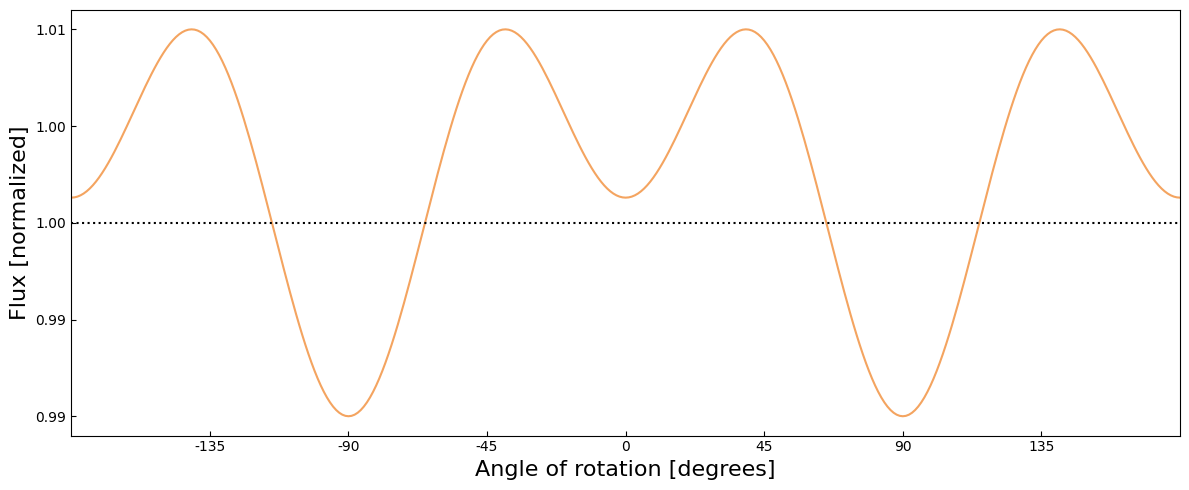

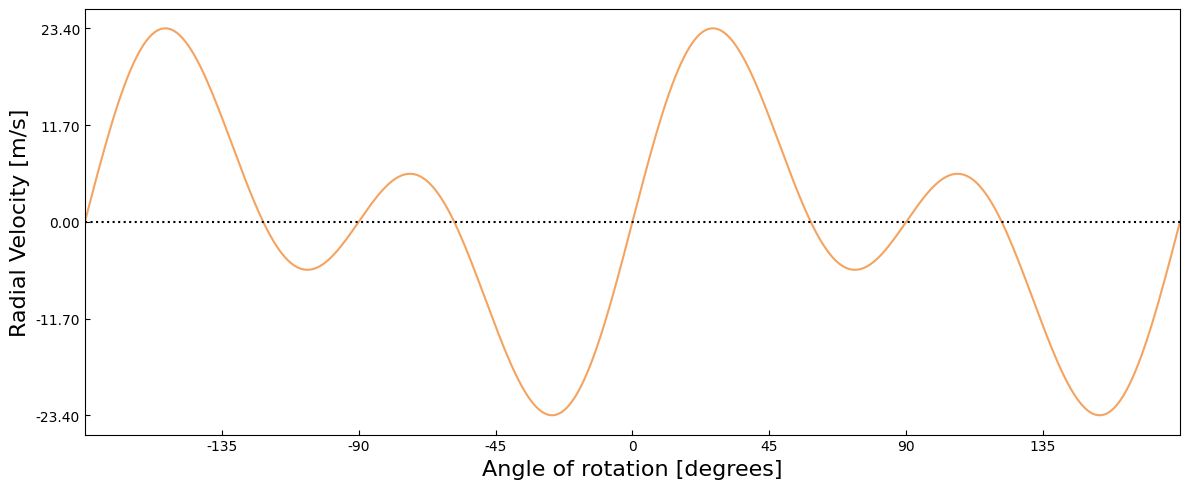

In [ ]:
s1.map[0,0] = 1
s1.map[1:,:] = obs_sum
s1.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.bam)
create_rv.flux_rv_line(s1)

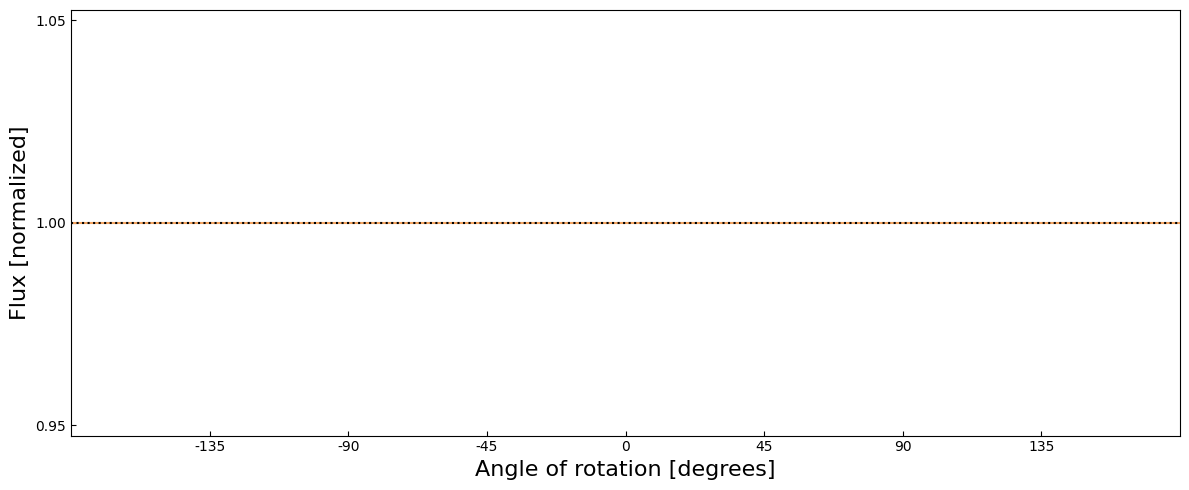

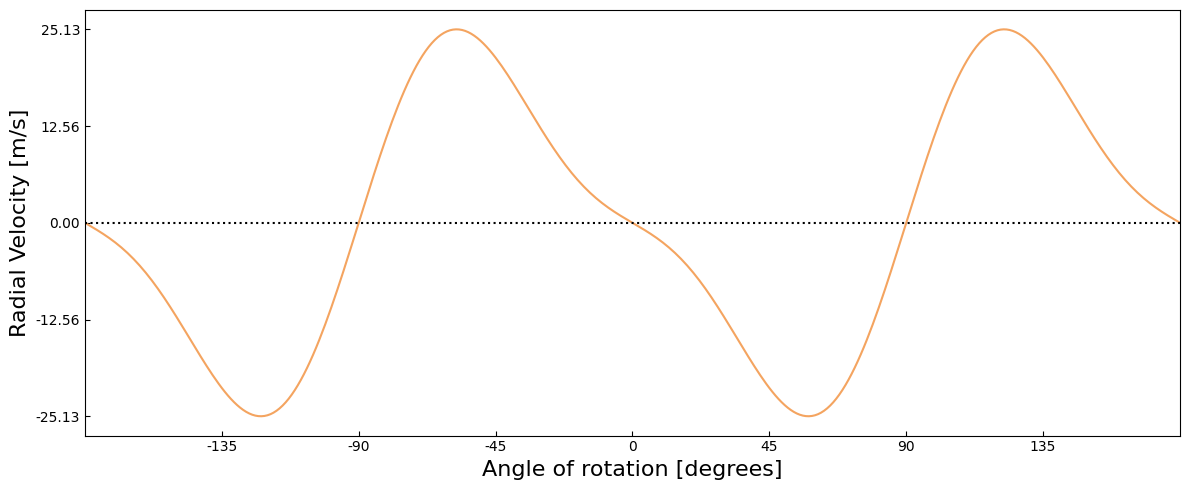

In [ ]:
s1.map[0,0] = 1
s1.map[1:,:] = null_sum
s1.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.bam)
create_rv.flux_rv_line(s1)

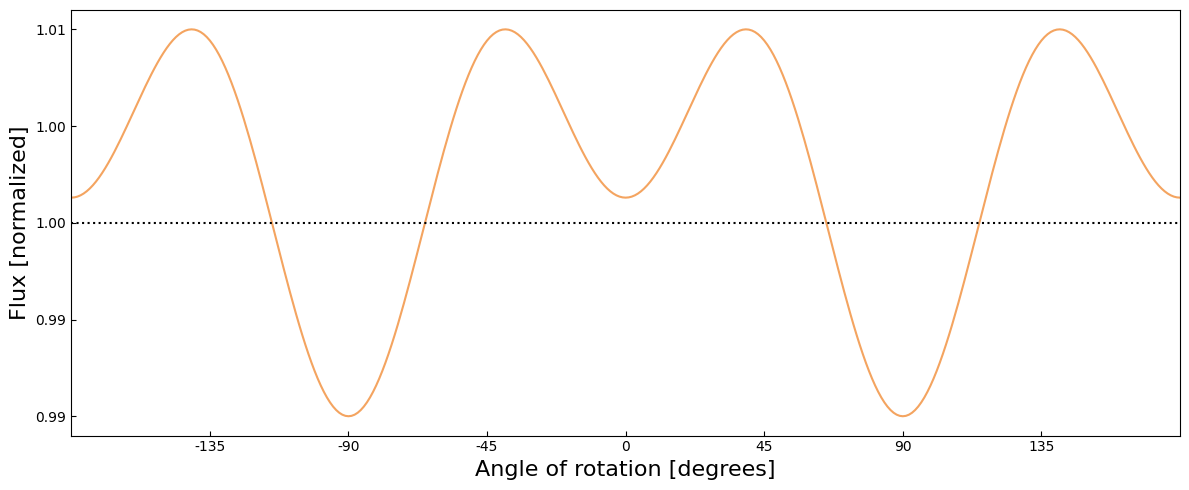

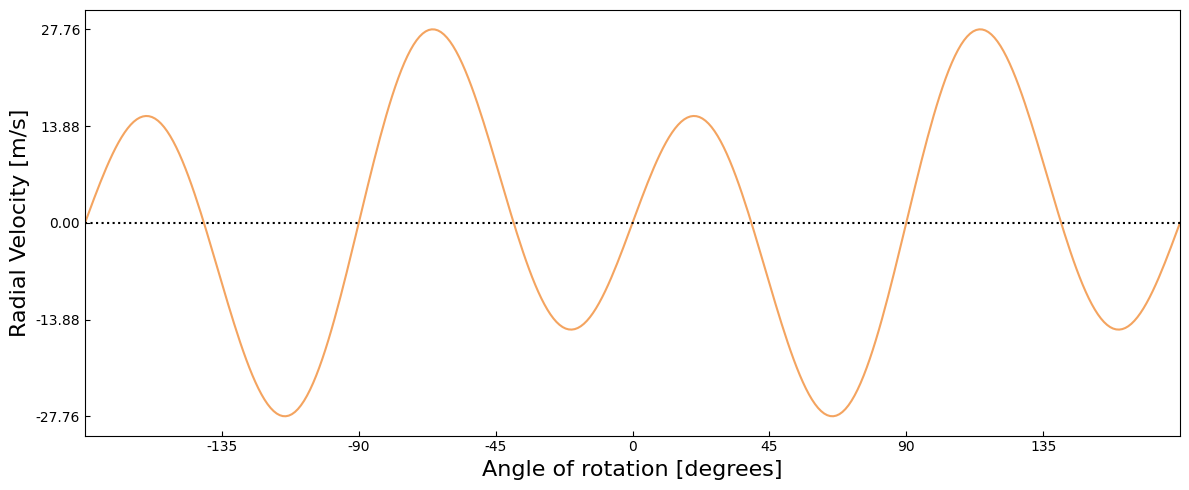

In [ ]:
s1.map[0,0] = 1
s1.map[1:,:] = obs_sum + null_sum
s1.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.bam)
create_rv.flux_rv_line(s1)

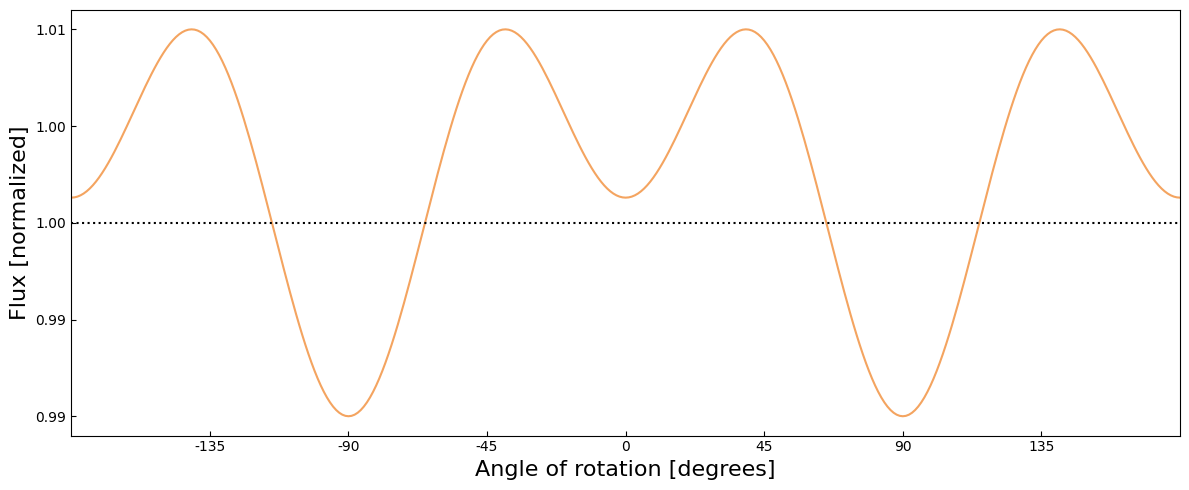

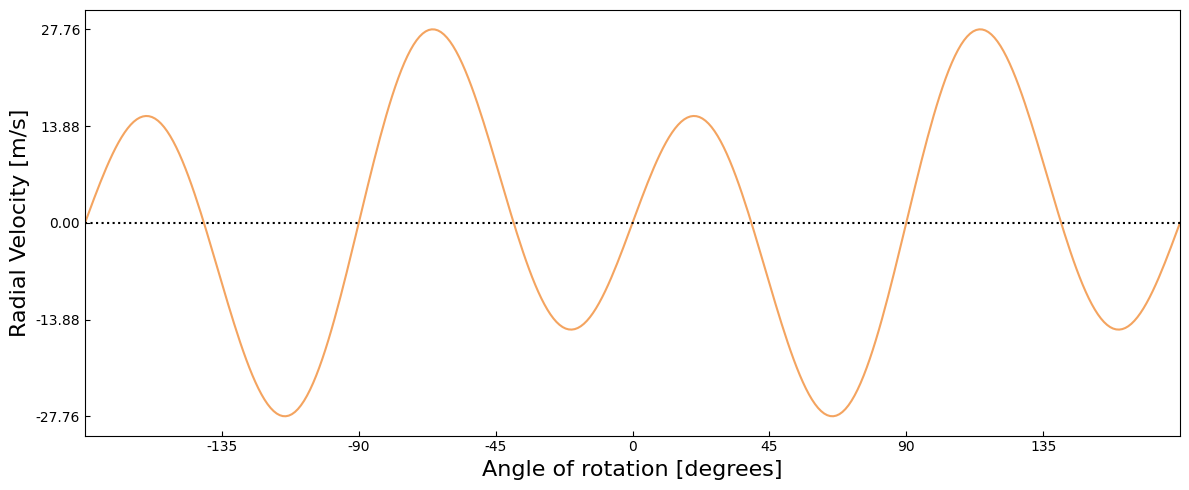

In [ ]:
s1.map[0,0] = 1
s1.map[1:,:] = harms[1:]
s1.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.bam)
create_rv.flux_rv_line(s1)

In [ ]:
# np.sum(obs,axis=0) + np.sum(null,axis=0)
# np.sum(weights[:, np.newaxis]*no_uni_eigens,axis=0)

In [ ]:
eps_data = np.loadtxt("epsEri_map.txt")

fit = fc.Fit()
cfile = "../eridani.cfg"

fit.read_config(cfile)
cfg = fit.cfg

subdir = cfg.folder
outdir = cfg.outdir
totaldir = os.path.join(cfg.outdir, subdir)

if not os.path.isdir(outdir):
    os.mkdir(outdir)

if not os.path.isdir(totaldir):
    os.mkdir(totaldir)

lmax = cfg.sim.lmax
udeg = cfg.star.udeg

realistic_star, inv_realistic_star, uni_star_limb, uni_star, ratio_no_limb = create_real_null.set_up_stars(fit, np.ones(lmax), uni_comp=1)

In [ ]:
import healpy as hp

epsEri = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
epsEri.map.obl = -70

nside = hp.pixelfunc.get_nside(eps_data)

In [ ]:
from functools import partial
vec2pix_func = partial(hp.vec2pix, nside)

proj = hp.projector.CartesianProj(
    lonra=[-180,180],
    latra=[-90,90],
    xsize=3000,
    ysize=3000
)

cart_map = proj.projmap(eps_data, vec2pix_func)

#flip map to be accurate since Healpix data is inverted
epsEri.map.load(cart_map[::-1])

harms = epsEri.map.y.eval()

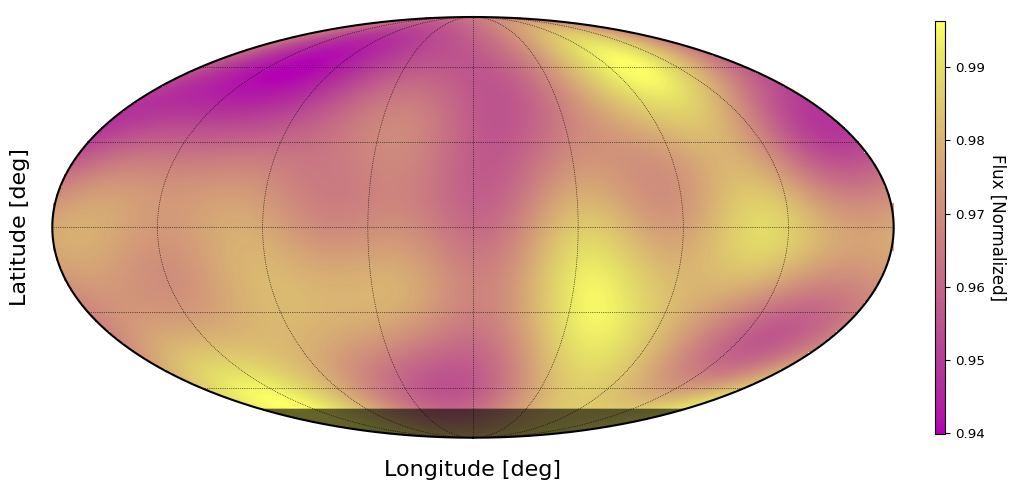

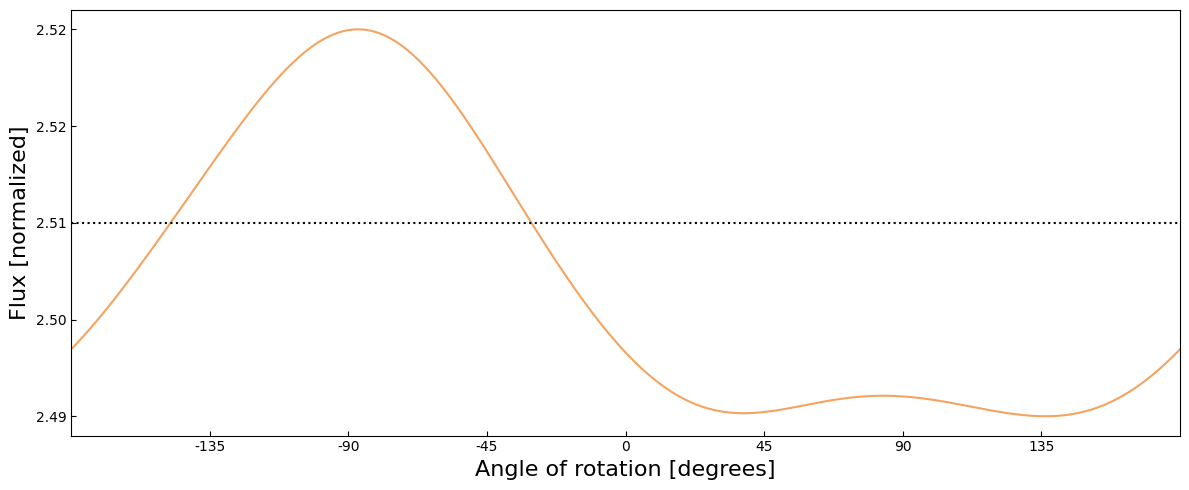

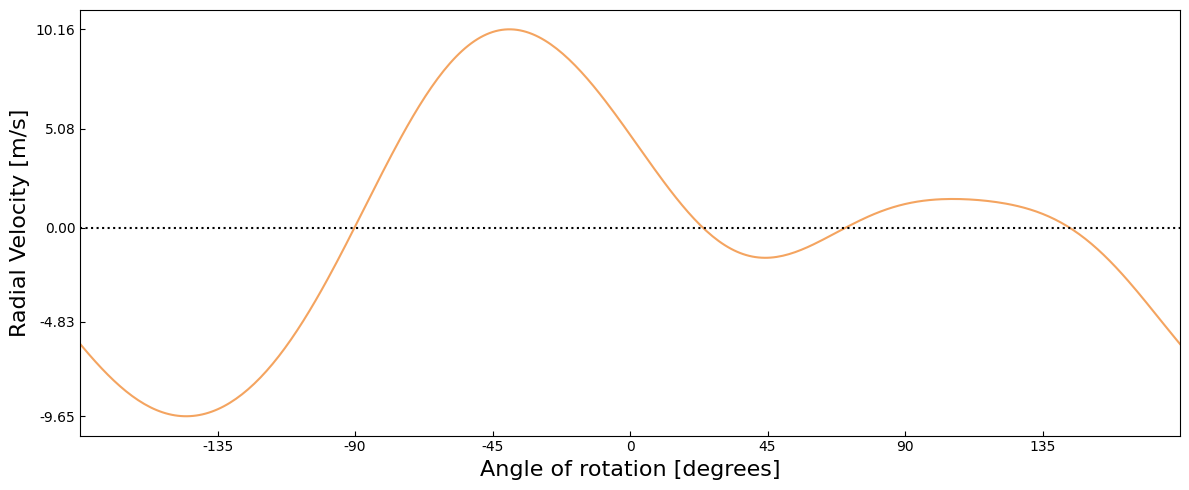

In [ ]:
epsEri.map[1:,:] = harms[1:]

create_emaps.emap_plot(epsEri,cmap=cm.buda)
epsEri.map.amp *= ratio_no_limb
create_rv.flux_rv_line(epsEri)
epsEri.map.amp /= ratio_no_limb

In [ ]:
base_eigens = np.loadtxt("../eridani-outputs/quad-limb-70i/stored-eigens/eigeny.txt")
no_uni_eigens = base_eigens[:,1:]

m1 = no_uni_eigens.T
m2 = harms[1:]
weights = np.linalg.solve(m1,m2)

In [ ]:
np.allclose(harms[1:],np.sum(weights[:, np.newaxis]*no_uni_eigens,axis=0))

True

In [ ]:
obs = (weights[:, np.newaxis]*no_uni_eigens)[:10]
null = (weights[:, np.newaxis]*no_uni_eigens)[10:]

obs_sum = np.sum(obs,axis=0)
null_sum = np.sum(null,axis=0)

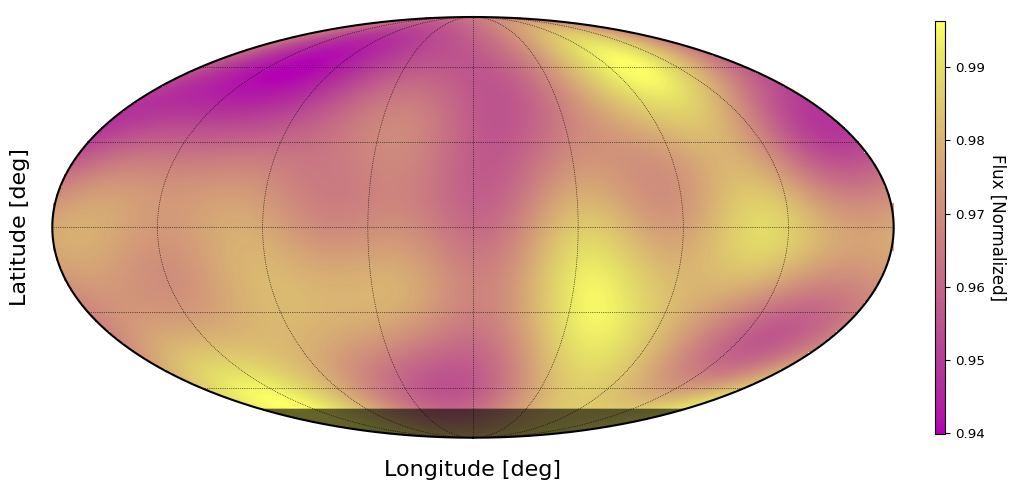

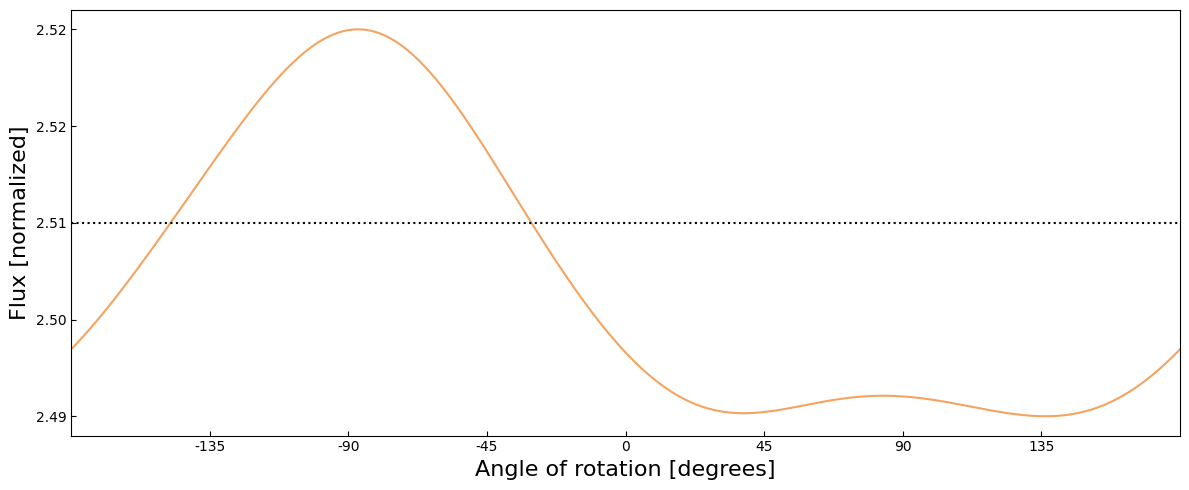

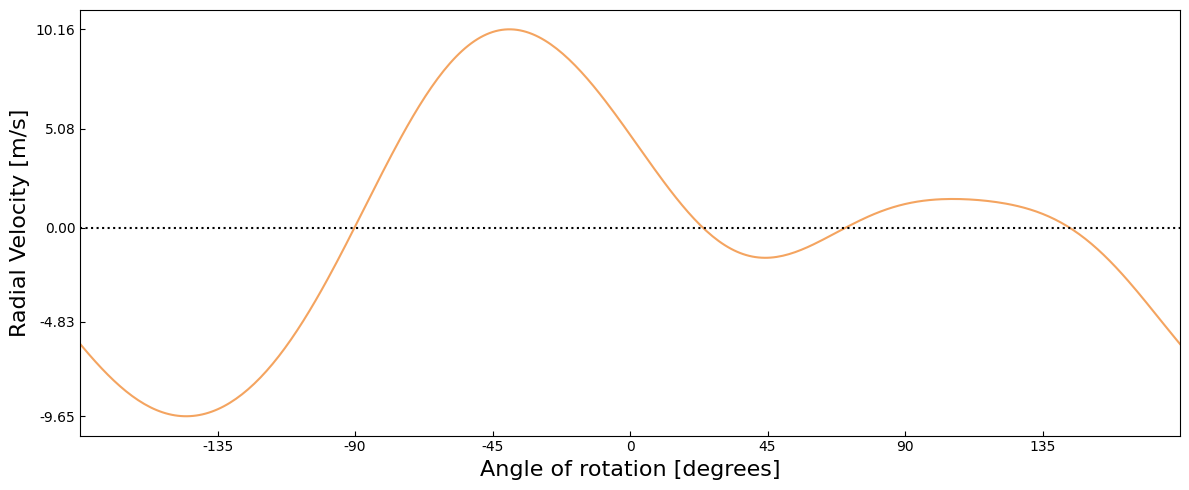

In [ ]:
epsEri.map[1:,:] = harms[1:]
create_emaps.emap_plot(epsEri,cmap=cm.buda)
epsEri.map.amp *= ratio_no_limb
epsEri.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.buda,
                colorbar=True,display_html=False)
create_rv.flux_rv_line(epsEri)
epsEri.map.amp /= ratio_no_limb

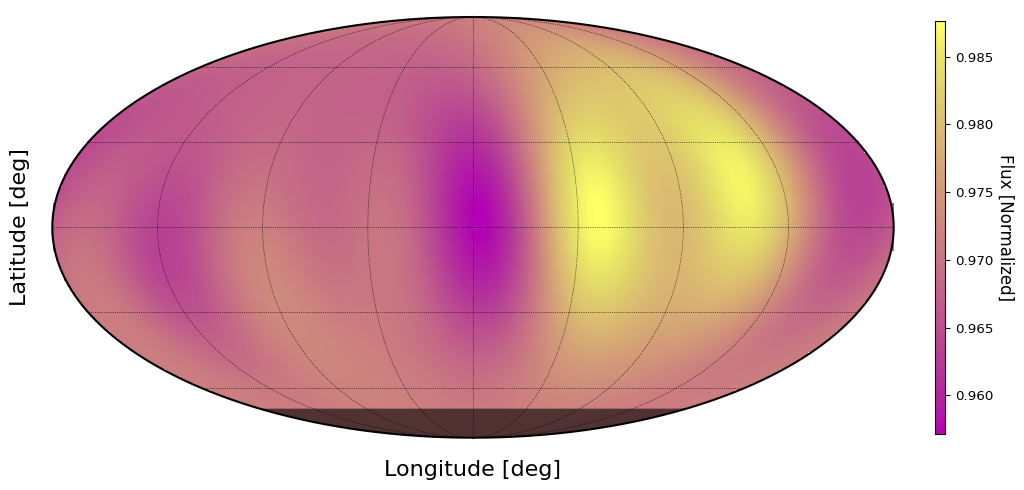

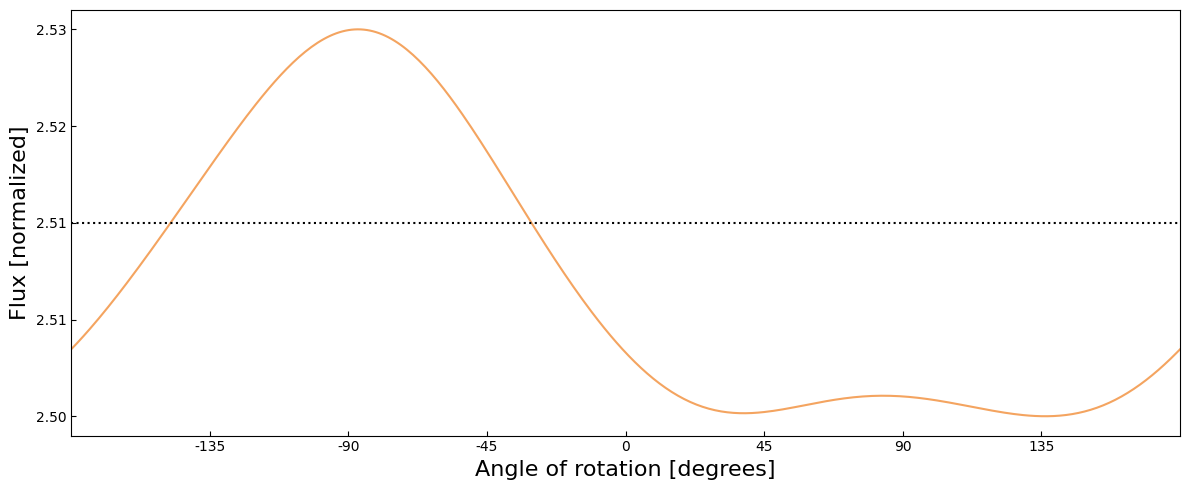

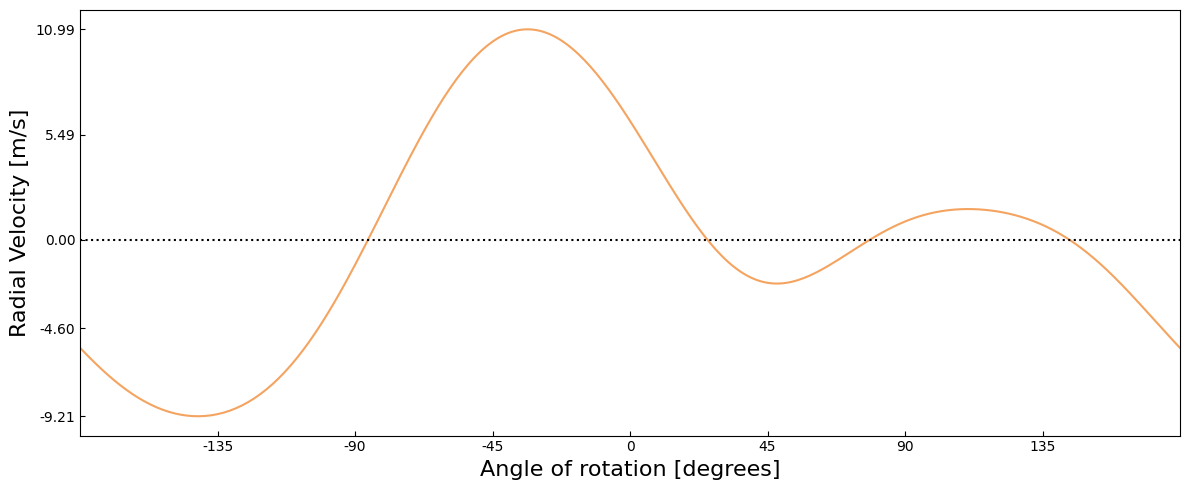

In [ ]:
epsEri.map[1:,:] = obs_sum
create_emaps.emap_plot(epsEri,cmap=cm.buda)
epsEri.map.amp *= ratio_no_limb
epsEri.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.buda,colorbar=True)
create_rv.flux_rv_line(epsEri)
epsEri.map.amp /= ratio_no_limb

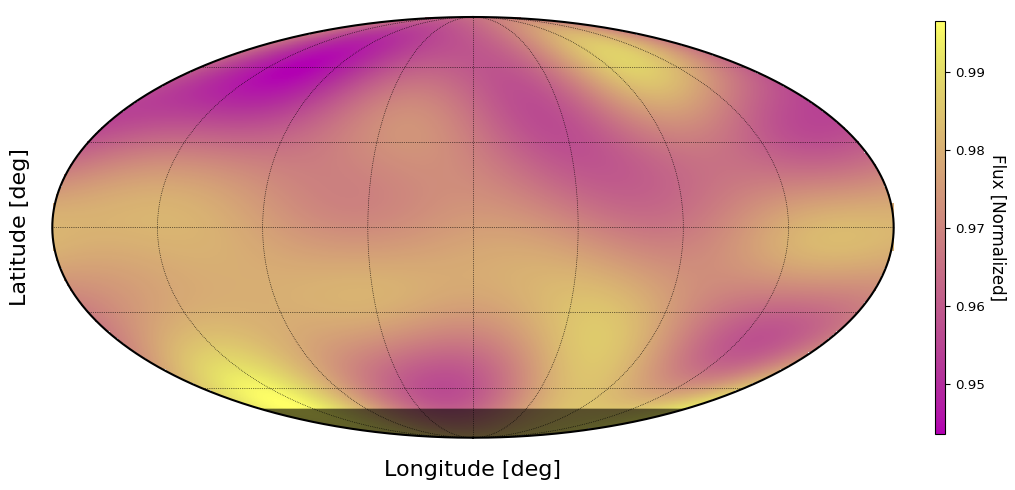

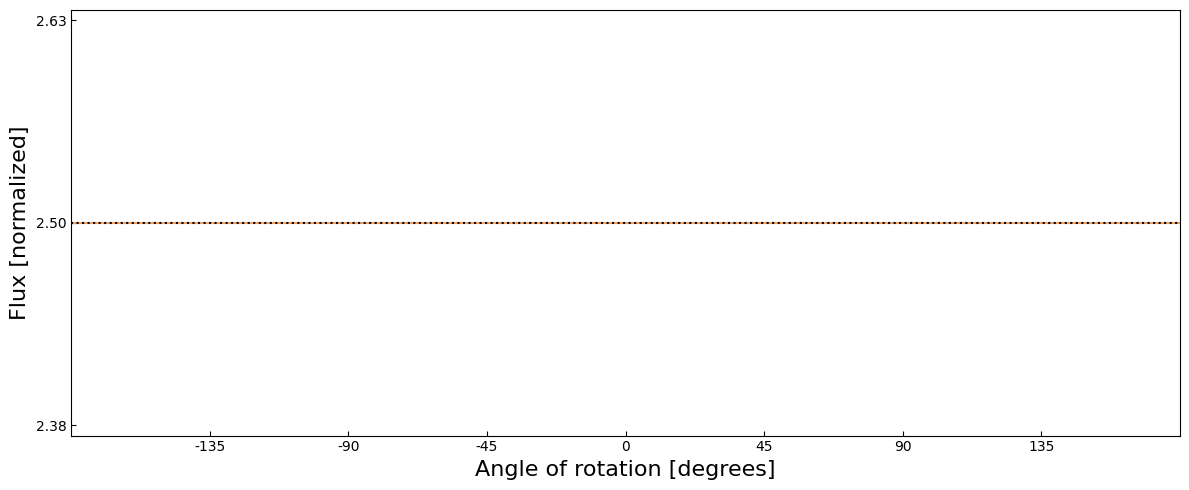

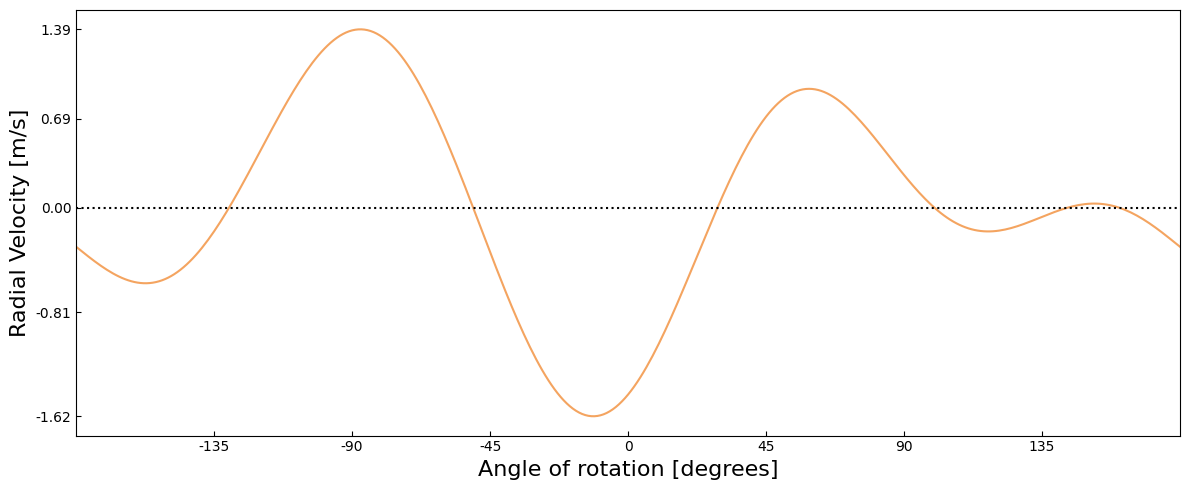

In [ ]:
epsEri.map[1:,:] = null_sum
create_emaps.emap_plot(epsEri,cmap=cm.buda)
epsEri.map.amp *= ratio_no_limb
epsEri.map.show(theta=np.linspace(0,360,91),rv=False,dpi=100,cmap=cm.buda,colorbar=True)
create_rv.flux_rv_line(epsEri)
epsEri.map.amp /= ratio_no_limb

## PCA Test - June 24th

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

def ppca(arr, ncomp=None):
    #Run PCA using ncomp and svd_solver = "full"
    pca = PCA(n_components=ncomp, svd_solver = "full")
    # pca.fit(arr.T)
    proj = pca.fit_transform(arr.T).T

    #Extract needed eigen information from PCA fit
    evalues  = pca.explained_variance_
    evectors = pca.components_
    evectors = evectors.T

    # print(pca.transform(arr.T).shape)

    # proj = np.dot(arr.T,evectors).T
            
        
    return evalues, evectors, proj

In [ ]:
from sklearn.decomposition import TruncatedSVD
def TSVD(arr, ncomp=None):
    svd = TruncatedSVD(n_components=ncomp, algorithm="randomized")
    proj = svd.fit_transform(arr.T).T
    evalues  = svd.explained_variance_
    evectors = svd.components_.T

    return evalues, evectors, proj

In [ ]:
nt = 8145
use_y00 = False
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
lmax = cfg.sim.lmax
ncurves = int((lmax + 1) ** 2 - 1)

#Set up needed arrays
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True

star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  -1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 1

        
# Run PCA to create orthogonal eigencurve basis set
evalues, evectors, proj = ppca(lcs, ncomp=ncurves)

# Discard imaginary part of eigens to appease numpy
proj = np.real(proj)
evalues = np.real(evalues)
evectors = np.real(evectors)

# Utilize eigens to generate eigenmaps using spherical harmonic coefficients
eigeny = np.zeros((ncurves, (lmax + 1)**2))
eigeny[:,0] = 1.0 # Y00 = 1 for all maps

for j in range(ncurves):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along one dimension)
            eigeny[j,yi] = evectors.T[j,shi]
            yi  += 1
            shi += 1

eigeny.shape, evalues.shape, evectors.shape, proj.shape, lcs.shape

In [ ]:
for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(proj[i][:],proj[j][:]),0):
                print("uh oh again!")

In [ ]:
np.allclose(np.dot(lcs.T, evectors).T,proj)

In [ ]:
# create_emaps.create_emaps(star, eigeny, emaps_path=None)
# create_emaps.create_eflux(star, eigeny, emaps_path=None,ticks=True)

In [ ]:
lcs_centered = lcs - np.mean(lcs, axis=1, keepdims=True)
manual_proj = np.dot(lcs_centered.T, evectors).T

# 3. This will now return True
print(np.allclose(manual_proj, proj))

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar = star.map.design_matrix(theta=thet).eval().T[1:,:]

In [ ]:
mstar.shape

In [ ]:
mstar[0]

In [ ]:
lcs[0]

In [ ]:
np.allclose(-lcs,mstar)

In [ ]:
neg_mstar = -mstar

In [ ]:
mm_star = np.concatenate((mstar,neg_mstar))

In [ ]:
np.mean(mm_star.T, axis=1, keepdims=True)

In [ ]:
a,b,c = ppca(mm_star, ncomp=70)
a.shape,b.shape,c.shape

In [ ]:
# Convert orthogonal light curves into maps        
eigeny = np.zeros((35, (lmax + 1)**2))
eigeny[:,0] = 1.0 # Y00 = 1 for all maps
for j in range(35):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along
            #  one dimension)
            eigeny[j,yi] = b.T[j,shi] - b.T[j,shi+35]
            yi  += 1
            shi += 1


In [ ]:
# a,b,c = ppca(mstar, ncomp=35)
# a.shape,b.shape,c.shape

In [ ]:
# create_emaps.create_emaps(star, eigeny, emaps_path=None)
# create_emaps.create_eflux(star, eigeny, emaps_path=None,ticks=True)

In [ ]:
a

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar = star.map.design_matrix(theta=thet).eval().T

In [ ]:
# import scipy.linalg as la

# # Transpose the matrix to process rows as columns
# Q, R, P = la.qr(mstar.T, pivoting=True)

# tol = np.max(mstar.shape) * np.spacing(np.linalg.norm(mstar, ord=2))
# rank = np.sum(np.abs(np.diagonal(R)) > tol)

# # 4. Split the permuted row indices using the rank
# independent_row_indices = P[:rank]
# dependent_row_indices = P[rank:]

# # Sort them for readability
# independent_row_indices.sort()
# dependent_row_indices.sort()

# print(f"Numerical Rank: {rank}")
# print(f"Independent Row Indices ({len(independent_row_indices)}):", independent_row_indices)
# print(f"Dependent Row Indices ({len(dependent_row_indices)}):", dependent_row_indices)

In [ ]:
# star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
# mstar = star.map.design_matrix(theta=thet).eval().T[1:,:]

# mstar = (mstar - np.mean(mstar.T, axis=1))

# # Transpose the matrix to process rows as columns
# Q, R, P = la.qr(mstar.T, pivoting=True)

# tol = np.max(mstar.shape) * np.spacing(np.linalg.norm(mstar, ord=2))
# rank = np.sum(np.abs(np.diagonal(R)) > tol)

# # 4. Split the permuted row indices using the rank
# independent_row_indices = P[:rank]
# dependent_row_indices = P[rank:]

# # Sort them for readability
# independent_row_indices.sort()
# dependent_row_indices.sort()

# print(f"Numerical Rank: {rank}")
# print(f"Independent Row Indices ({len(independent_row_indices)}):", independent_row_indices)
# print(f"Dependent Row Indices ({len(dependent_row_indices)}):", dependent_row_indices)

In [ ]:
np.linalg.matrix_rank(mstar.T)

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar = star.map.design_matrix(theta=np.linspace(0,360,1000)).eval().T

U, s, Vh = np.linalg.svd(mstar.T)
U.shape,s.shape, Vh.shape

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar2 = star.map.design_matrix(theta=np.linspace(0,360,1000)).eval().T[1:,:]

U2, s2, Vh2 = np.linalg.svd(mstar2.T)
U2.shape,s2.shape, Vh2.shape

In [ ]:
Vh22 = np.insert(Vh2, 0, np.ones(35), axis=1)
# Vh22[0].shape

In [ ]:
create_emaps.create_emaps(star, Vh22, emaps_path=None)
create_emaps.create_eflux(star, Vh22, emaps_path=None,ticks=True)

In [ ]:
# np.linalg.matrix_rank(Vh.T)

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar = star.map.design_matrix(theta=np.linspace(0,360,1000)).eval().T

In [ ]:
a,b,c = ppca(mstar, ncomp=36)
a.shape,b.shape,c.shape

In [ ]:
np.linalg.matrix_rank(c)

In [ ]:
test_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
test_star.map[:,:] = b.T[-1]

In [ ]:
print(list(test_star.map.flux(theta=thet).eval()))
test_star.map.show(rv=False,theta=np.linspace(0,361,91),colorbar=True,dpi=100)
create_rv.flux_rv_line(test_star,flux_only=True)

In [ ]:
# b.T[-1]

In [ ]:
create_emaps.create_emaps(star, b.T, emaps_path=None)
create_emaps.create_eflux(star, b.T, emaps_path=None,ticks=True)

In [ ]:
# # Create a zero matrix of shape (8145, 36) to match the inner dimensions
# Sigma = np.zeros((1000, 36))

# # Populate the top 36x36 block with the diagonal of s
# Sigma[:36, :36] = np.diag(s)

# np.dot(np.dot(U,Sigma),Vh)

In [ ]:
mecurv = np.dot(mstar.T,Vh).T
mecurv.shape

In [ ]:
mecurv = np.dot(mstar.T,Vh).T
mecurv.shape

In [ ]:
for i in range(len(Vh)):
    for j in range(len(Vh)):
        if i != j:
            if not np.isclose(np.dot(Vh.T[i][:],Vh.T[j][:]),0):
                print("uh oh again!")

In [ ]:
test_star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
test_star.map[:,:] = Vh[0]

In [ ]:
# print(list(test_star.map.flux(theta=thet).eval()))

In [ ]:
# test_star.map.show(rv=False,theta=np.linspace(0,361,91),colorbar=True)

In [ ]:
old_00 = Vh[:,0]
Vh[:,0] = 1

In [ ]:
create_emaps.create_emaps(star, Vh, emaps_path=None)
create_emaps.create_eflux(star, Vh, emaps_path=None,ticks=True)

In [ ]:
create_emaps.create_emaps(star, Vh[1:,:], emaps_path=None)
create_emaps.create_eflux(star, Vh[1:,:], emaps_path=None,ticks=True)

In [ ]:
eigeny0 = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/eigeny.txt")

create_emaps.create_emaps(star, eigeny0, emaps_path=None)
create_emaps.create_eflux(star, eigeny0, emaps_path=None,ticks=True)

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
mstar = star.map.design_matrix(theta=thet).eval().T[1:,:]

U2, s2, Vh2 = np.linalg.svd(mstar.T)
U2.shape,s2.shape, Vh2.shape

In [ ]:
Vh[0]

In [ ]:
Vh2[1]

In [ ]:
# np.linalg.matrix_rank(mstar)

In [ ]:
np.allclose(c,np.dot(b,mm_star))

In [ ]:
nt = 8145
use_y00 = False
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
lmax = cfg.sim.lmax
ncurves = int((lmax + 1) ** 2 - 1) * 2

#Set up needed arrays
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True

# star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] =  -1 #set the map based on factor
        lcs[ind+1] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 2

np.mean(lcs, axis=1, keepdims=True)

In [ ]:
m_proj = np.dot(lcs_centered.T, evectors).T
np.dot(m_proj,m_proj.T)

In [ ]:
eigeny0 = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/eigeny.txt")
evectors0 = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/evectors.txt")
ecurves0 = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/ecurves.txt")
evalues0 =  np.loadtxt("../eridani-outputs/results-70i/stored-eigens/evalues.txt")
lcs0 = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/lcs.txt")

In [ ]:
np.allclose(proj,ecurves0)

In [ ]:
# np.einsum('ij,kj->ik', proj, proj)[0]

In [ ]:
# np.allclose(ecurves0,proj)

In [ ]:
np.dot(lcs.T,evectors)

In [ ]:
evalues

In [ ]:
for i in range(len(ecurves)):
    for j in range(len(ecurves)):
        if i != j:
            if not np.isclose(np.dot(ecurves[i][:],ecurves[j][:]),0):
                print("uh oh again!")

In [ ]:
for i in range(len(ecurves)):
    for j in range(len(ecurves)):
        if i != j:
            if not np.isclose(np.dot(ecurves[i][:],ecurves[j][:]),0):
                print("uh oh again!")
        else:
            print(np.dot(ecurves[i][:],ecurves[j][:]) / evalues[i])

In [ ]:
np.allclose(np.dot(eigeny[:,1:],eigeny[:,1:].T),np.identity(35))

In [ ]:
np.allclose(np.dot(evectors,evectors.T),np.identity(35))

In [ ]:
np.allclose(np.dot(ecurves,ecurves.T),np.identity(35))

In [ ]:
(np.identity(35)/8144)

In [ ]:
np.einsum('ij,kj->ik', ecurves, ecurves)[0]

In [ ]:
# [print(x) for x in (np.dot(ecurves,ecurves.T))]
pass

In [ ]:
# [print(x) for x in ecurves]
pass

In [ ]:
# print("Shape:", ecurves.shape)
# print("Dtype:", ecurves.dtype)
# print("Type: ", type(ecurves))

In [ ]:
np.dot(ecurves[0],ecurves[0])

In [ ]:
test = np.dot(ecurves.T, np.linalg.inv(np.identity(35) * evalues))

In [ ]:
evalues

In [ ]:
ecurves2 = np.loadtxt("../eridani-outputs/results-70i-test/stored-eigens/ecurves.txt")
evalues2 = np.loadtxt("../eridani-outputs/results-70i-test/stored-eigens/evalues.txt")

In [ ]:
np.dot(ecurves2,ecurves2.T)[0]

In [ ]:
(np.dot(ecurves2,ecurves2.T) * (np.identity(35)/999))

In [ ]:
(np.dot(ecurves2,ecurves2.T) * (np.identity(35)*evalues2))[3]

In [ ]:
evalues2

In [ ]:
for i in range(len(ecurves2)):
    for j in range(len(ecurves2)):
        if i != j:
            if not np.isclose(np.dot(ecurves2[i][:],ecurves2[j][:]),0):
                print("uh oh again!")
        else:
            print(np.dot(ecurves2[i][:],ecurves2[j][:]) / evalues2[i])

In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)

im = np.identity(35)

for i in range(len(im)):
    for j in range(len(im)):
        if i != j:
            if not np.isclose(np.dot(im[i][:],im[j][:]),0):
                print("uh oh again!")

In [ ]:
nt = 1000
use_y00 = False
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)
lmax = cfg.sim.lmax
nharm = int((lmax + 1) ** 2 - 1)
ncurves = nharm * 2

#Set up needed arrays
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True
if not use_y00:
    star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] =  -1 #set the map based on factor
        lcs[ind+1] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 2

        
# Run PCA to create orthogonal eigencurve basis set
evalues, evectors, proj = pca.pca(lcs, ncomp=nharm)

# Discard imaginary part of eigens to appease numpy
proj = np.real(proj)
evalues = np.real(evalues)
evectors = np.real(evectors)

# Utilize eigens to generate eigenmaps using spherical harmonic coefficients
eigeny = np.zeros((nharm, (lmax + 1)**2))
# eigeny[:,0] = 1.0 # Y00 = 1 for all maps

for j in range(nharm):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along one dimension)
            eigeny[j,yi] = evectors.T[j,shi] - evectors.T[j,shi+1]
            yi  += 1
            shi += 2

print("Shapes:", eigeny.shape, evalues.shape, evectors.shape, proj.shape, lcs.shape)

In [ ]:
for i in range(len(proj)):
    print(np.dot(eigeny[i][1:],eigeny[i][1:]))

In [ ]:
for i in range(len(lcs)):
    for j in range(len(lcs)):
        if i != j:
            if not np.isclose(np.dot(lcs[i][:],lcs[j][:]),0):
                print("uh oh!")

In [ ]:
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))
ncurves = int((lmax + 1) ** 2 - 1)

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True

star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[1:,:] =  eigeny[ind][1:] #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[:,:] = 0.0 #reset map to initial state
        ind += 1

In [ ]:
for i in range(len(lcs)):
    for j in range(len(lcs)):
        if i != j:
            if not np.isclose(np.dot(lcs[i][:],lcs[j][:]),0):
                print("uh oh!")

In [ ]:
for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(proj[i],proj[j]),0):
                print("uh oh!")

for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(eigeny[i][:],eigeny[j][:]),0):
                print("uh oh again!")

In [ ]:
create_emaps.create_emaps(star, eigeny, emaps_path=None)
create_emaps.create_eflux(star, eigeny, emaps_path=None,ticks=True)

In [ ]:
#Set up needed arrays
nt = 8145
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))
ncurves = int((lmax + 1) ** 2 - 1)

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True
if not use_y00:
    star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 1

        
# Run PCA to create orthogonal eigencurve basis set
evalues, evectors, proj = pca.pca(lcs, ncomp=ncurves)

# Discard imaginary part of eigens to appease numpy
proj = np.real(proj)
evalues = np.real(evalues)
evectors = np.real(evectors)

# Utilize eigens to generate eigenmaps using spherical harmonic coefficients
eigeny2 = np.zeros((ncurves, (lmax + 1)**2))
# eigeny2[:,0] = 1.0 # Y00 = 1 for all maps

for j in range(ncurves):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along one dimension)
            eigeny2[j,yi] = evectors.T[j,shi]
            yi  += 1
            shi += 1

# eigeny2, evalues, evectors, proj, lcs


In [ ]:
for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(proj[i],proj[j]),0):
                print("uh oh!")

for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(eigeny2[i][1:],eigeny2[j][1:]),0):
                print("uh oh!")

In [ ]:
eigeny2[-1]

In [ ]:
create_emaps.create_emaps(star, eigeny2, emaps_path=None)
create_emaps.create_eflux(star, eigeny2, emaps_path=None,ticks=True)

In [ ]:
eigeny[10] / eigeny2[10]

In [ ]:
eigeny[10]

In [ ]:
eigeny2[10]

In [ ]:
eigeny = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/eigeny.txt")

In [ ]:
for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(proj[i],proj[j]),0):
                print("uh oh!")

for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(eigeny[i][1:],eigeny[j][1:]),0):
                print("uh oh!")

In [ ]:
for i in range(len(proj)):
    for j in range(len(proj)):
        if i != j:
            if not np.isclose(np.dot(eigeny[i][1:],eigeny[j][1:]),0):
                print("uh oh!")

In [ ]:
for i in range(len(proj)):
    print(np.dot(eigeny[i][1:],eigeny[i][1:]))

In [ ]:
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))
ncurves = int((lmax + 1) ** 2 - 1)

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True

star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[1:,:] =  eigeny[ind][1:] #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[:, :] = 0.0 #reset map to initial state
        ind += 1

In [ ]:
# for i in range(len(lcs)):
#     for j in range(len(lcs)):
#         if i != j:
#             if not np.isclose(np.dot(lcs[i][:],lcs[j][:]),0):
#                 print("uh oh!")

In [ ]:
assert True == False

In [ ]:
import sklearn
import sklearn.decomposition

def TSVD(arr,ncomp):
    nt = arr.shape[1]

    tpca = sklearn.decomposition.TruncatedSVD(n_components=ncomp)
    tpca.fit(arr.T)
    evalues  = tpca.explained_variance_
    evectors = tpca.components_
    proj = np.zeros((ncomp, nt))
    for i in range(ncomp):
        proj[i] = np.sum(evectors[i] * arr.T, axis=1)

    evectors = evectors.T

    return evalues, evectors, proj


In [ ]:
from sklearn.decomposition import PCA

def pca(arr, ncomp=None):
    #Run PCA using ncomp and svd_solver = "full"
    pca = PCA(n_components=ncomp, svd_solver = "full")
    pca.fit(arr.T)

    #Extract needed eigen information from PCA fit
    evalues  = pca.explained_variance_
    evectors = pca.components_
    evectors = evectors.T
    emean = pca.mean_

    # Generate ecurves design matrix (proj)
    arr = arr.T
    m = (arr - emean).T
    proj = np.dot(m.T,evectors).T
            
        
    return evalues, evectors, proj


In [ ]:
star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)


In [ ]:
x = star.map.design_matrix(theta=np.linspace(0,360,361)).eval()

In [ ]:
#Set up needed arrays
thet = np.linspace(0,360,361)
lcs = np.zeros((35, 361))

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True

star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 1

In [ ]:
x[:,1:].shape

In [ ]:
lcs.T.shape

In [ ]:
np.all(lcs.T == x[:,1:])

In [ ]:
assert True == False

In [ ]:
use_y00 = False
nlcs    = 8145
lmax = cfg.sim.lmax
ncurves = int((lmax + 1) ** 2 - 1)
nlcs = cfg.sim.nlcs
nt = nlcs

star = utils.initstar(fit, lmax, udeg=udeg, include_rv=False)


# Create harmonic maps of the planet, excluding Y00
# (lmax**2 maps, plus a negative version for all but Y00)
if not use_y00:
        star.map[:,:] = 0

ncurves *=2
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))
ncurves //= 2
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):           
        star.map[l, m] =  1.0
        lcs[ind]   = star.map.flux(theta=thet).eval()
        star.map[l, m] = -1.0
        lcs[ind+1] = star.map.flux(theta=thet).eval()
        star.map[l, m] = 0.0
        ind += 2
    
evalues, evectors, proj = pca(lcs, ncomp=ncurves)

# Discard imaginary part of eigencurves to appease numpy
proj = np.real(proj)

# Convert orthogonal light curves into maps        
eigeny = np.zeros((ncurves, (lmax + 1)**2))
eigeny[:,0] = 1.0 # Y00 = 1 for all maps
for j in range(ncurves):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along
            #  one dimension)
            eigeny[j,yi] = evectors.T[j,shi] - evectors.T[j,shi+1]
            yi  += 1
            shi += 2

eigeny.shape, evalues.shape, evectors.shape, proj.shape, lcs.shape

In [ ]:

eigeny2, evalues2, evectors2, proj2, lcs2 = eigeny, evalues, evectors, proj, lcs

In [ ]:
lcs2.shape

In [ ]:
np.sum(lcs2[:6],axis=0)

In [ ]:
# star.map[:,:] = eigeny[20]
# print(star.map.flux(theta=np.linspace(0,360,361)).eval())
# star.map[:,:] = 0
# star.map[0,0] = 1

In [ ]:
# create_emaps.create_emaps(star, eigeny, emaps_path=None)
# create_emaps.create_eflux(star, eigeny, emaps_path=None)

In [ ]:
#Set up needed arrays
thet = np.linspace(0, 360, nt)
lcs = np.zeros((ncurves, nt))

# Remove uniform component from light curves if use_y00 == False
# starry includes this by default, so no changes needed if use_y00 == True
if not use_y00:
    star.map[:,:] = 0

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=thet).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 1

        
# Run PCA to create orthogonal eigencurve basis set
evalues, evectors, proj = pca(lcs, ncomp=ncurves)

# Discard imaginary part of eigens to appease numpy
proj = np.real(proj)
evalues = np.real(evalues)
evectors = np.real(evectors)

# Utilize eigens to generate eigenmaps using spherical harmonic coefficients
eigeny = np.zeros((ncurves, (lmax + 1)**2))
eigeny[:,0] = 1.0 # Y00 = 1 for all maps

for j in range(ncurves):
    yi  = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            # (ok because evectors has only been sorted along one dimension)
            eigeny[j,yi] = evectors.T[j,shi]
            yi  += 1
            shi += 1

eigeny.shape, evalues.shape, evectors.shape, proj.shape, lcs.shape

In [ ]:
np.sqrt(2)

In [ ]:
eigeny2[1] / eigeny[1]

In [ ]:
import sklearn.decomposition
import numpy as np

# 1. Loop through positive harmonics exactly like your Method 2
# (Make sure use_y00 = False or star.map[:,:] = 0 is run first!)
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] = 1.0
        lcs[ind] = star.map.flux(theta=thet).eval()
        star.map[l, m] = 0.0
        ind += 1

# 2. FIX: Use TruncatedSVD instead of standard PCA
svd = sklearn.decomposition.TruncatedSVD(n_components=ncurves)
svd.fit(lcs.T)

evalues  = svd.explained_variance_
evectors = svd.components_.T  # Transpose to match your shape requirement

# 3. Project the uncentered data cleanly
proj = svd.transform(lcs.T).T

# 4. Map the eigenvectors directly (No subtraction needed!)
eigeny = np.zeros((ncurves, (lmax + 1)**2))
eigeny[:, 0] = 1.0 

for j in range(ncurves):
    yi = 1
    shi = 0
    for l in range(1, lmax + 1):
        for m in range(-l, l + 1):
            eigeny[j, yi] = evectors[shi, j]  # Maps perfectly now
            yi += 1
            shi += 1

In [ ]:
eigeny2 = eigeny
eigeny2

In [ ]:
# import sklearn.decomposition
# import numpy as np

# # 1. Loop through positive harmonics exactly like your Method 2
# # (Make sure use_y00 = False or star.map[:,:] = 0 is run first!)
# ind = 0
# for i, l in enumerate(range(1, lmax + 1)):
#     for j, m in enumerate(range(-l, l + 1)):  
#         star.map[l, m] = 1.0
#         lcs[ind] = star.map.flux(theta=thet).eval()
#         star.map[l, m] = 0.0
#         ind += 1

# # 2. FIX: Use TruncatedSVD instead of standard PCA
# svd = sklearn.decomposition.TruncatedSVD(n_components=ncurves, algorithm='arpack', 
#                                          random_state=42)
# svd.fit(lcs.T)

# evalues  = svd.explained_variance_
# evectors = svd.components_.T  # Transpose to match your shape requirement

# # 3. Project the uncentered data cleanly
# proj = svd.transform(lcs.T).T

# # 4. Map the eigenvectors directly (No subtraction needed!)
# eigeny = np.zeros((ncurves, (lmax + 1)**2))
# eigeny[:, 0] = 1.0 

# for j in range(ncurves):
#     yi = 1
#     shi = 0
#     for l in range(1, lmax + 1):
#         for m in range(-l, l + 1):
#             eigeny[j, yi] = evectors[shi, j]  # Maps perfectly now
#             yi += 1
#             shi += 1

In [ ]:
# eigeny3 = eigeny

In [ ]:
# import sklearn.decomposition
# import numpy as np

# # 1. Loop through positive harmonics exactly like your Method 2
# # (Make sure use_y00 = False or star.map[:,:] = 0 is run first!)
# ind = 0
# for i, l in enumerate(range(1, lmax + 1)):
#     for j, m in enumerate(range(-l, l + 1)):  
#         star.map[l, m] = 1.0
#         lcs[ind] = star.map.flux(theta=thet).eval()
#         star.map[l, m] = 0.0
#         ind += 1

# # 2. FIX: Use TruncatedSVD instead of standard PCA
# svd = sklearn.decomposition.TruncatedSVD(n_components=ncurves, algorithm='arpack', 
#                                          random_state=42)
# svd.fit(lcs.T)

# evalues  = svd.explained_variance_
# evectors = svd.components_.T  # Transpose to match your shape requirement

# # 3. Project the uncentered data cleanly
# proj = svd.transform(lcs.T).T

# # 4. Map the eigenvectors directly (No subtraction needed!)
# eigeny = np.zeros((ncurves, (lmax + 1)**2))
# eigeny[:, 0] = 1.0 

# for j in range(ncurves):
#     yi = 1
#     shi = 0
#     for l in range(1, lmax + 1):
#         for m in range(-l, l + 1):
#             eigeny[j, yi] = evectors[shi, j]  # Maps perfectly now
#             yi += 1
#             shi += 1

In [ ]:
# eigeny3[0] / eigeny

In [ ]:
# eigeny[0] / eigeny2[0]

In [ ]:
# star.map.y.eval()

In [ ]:
lcs = np.zeros((ncurves, 1000))
theta = np.linspace(0,360,1000)

# Loop through each harmonic map of the star, excluding Y00, to extract light curve
ind = 0
for i, l in enumerate(range(1, lmax + 1)):
    for j, m in enumerate(range(-l, l + 1)):  
        star.map[l, m] =  1 #set the map based on factor
        lcs[ind] = star.map.flux(theta=theta).eval()

        star.map[l, m] = 0.0 #reset map to initial state
        ind += 1

In [ ]:
lcs.T.shape

In [ ]:
lcs.T[0]

In [ ]:
# X[0]

In [ ]:
# X.shape

In [ ]:
# map_star.map

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import starry2 as starry
from sklearn.decomposition import PCA

# Ensure starry is in 2D mapping mode
starry.config.lazy = False

# # 1. Setup the starry map configurations
deg_max = 5          
n_y = (deg_max + 1)**2 - 1  # Total number of Ylm coefficients (36 for degree 5)
# inc = 60.0           # Inclination of the star/planet

# map_star =  utils.initstar(fit, lmax, udeg=udeg, include_rv=False)

# 2. Generate observation phases (rotational time series)
# t = np.linspace(0, 10, 1000) 
# th = (360.0 / 2.0) * t


# 3. Build the design matrix (Flux response per Ylm component)
# X = map_star.map.design_matrix(theta=np.linspace(0,360,1000)).eval()

# 4. Extract PCA components for BOTH observable and null spaces
# To extract the full basis set, we set n_components to the full number of Ylm features
pca = PCA(n_components=n_y, svd_solver = 'full')
pca.fit(x[:,1:])

# 5. Create the full 'eigeny' basis set
eigeny = np.zeros((n_y, n_y))
eigeny[:, 1:] = pca.components_[:, 1:] 

# 6. Separate Observable Eigenmaps from the Null Space
# We check the explained variance ratio. If it drops past a strict numerical 
# threshold (e.g., 1e-7), it means the light curve cannot see it.
threshold = 1e-7
observable_idx = np.where(pca.explained_variance_ratio_ >= threshold)[0]
null_space_idx = np.where(pca.explained_variance_ratio_ < threshold)[0]

print(f"Total Basis Vectors: {len(eigeny)}")
print(f"Observable Vectors: {len(observable_idx)}")
print(f"Null Space Vectors: {len(null_space_idx)}")

# # 7. Plotting the top observable vs top null space maps
# fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# # Row 0: Strongest Observable Eigenmaps
# for i, idx in enumerate(observable_idx[:4]):
#     ax = axes[0, i]
#     basis_map = starry.Map(ydeg=deg_max, inc=inc)
#     basis_map[1:, :] = eigeny[idx, 1:]
#     basis_map.show(ax=ax, projection="ortho")
#     ax.set_title(f"eigeny[{idx}] (Observable)\nVar: {pca.explained_variance_ratio_[idx]:.2%}")

# # Row 1: True Null Space Maps (Variance ~ 0%)
# for i, idx in enumerate(null_space_idx[:4]):
#     ax = axes[1, i]
#     basis_map = starry.Map(ydeg=deg_max, inc=inc)
#     basis_map[1:, :] = eigeny[idx, 1:]
#     basis_map.show(ax=ax, projection="ortho")
#     ax.set_title(f"eigeny[{idx}] (Null Space)\nVar: {pca.explained_variance_ratio_[idx]:.2e}%")

# plt.suptitle("The Complete Basis Set (`eigeny`) Divided by Observability", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

In [ ]:
eigeny[0].shape

In [ ]:
# np.all(eigeny2==eigeny3)

In [ ]:
# np.sum(eigeny2,axis=1)

In [ ]:
# create_emaps.create_emaps(star, eigeny2, emaps_path=None)
# create_emaps.create_emaps(star, eigeny3, emaps_path=None)

## Testing Plotting Functionality - June 23rd

In [ ]:
base_eigens = np.loadtxt("../eridani-outputs/results-70i/stored-eigens/eigeny.txt")
norm_eigens = np.loadtxt("../eridani-outputs/results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

s1 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
s2 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

In [ ]:
base_eigens[0]

In [ ]:
base_eigens.shape

In [ ]:
# s1.map[:,:] = base_eigens[10]
# s2.map[:,:] = norm_eigens[10]

In [ ]:
# s1.map.show(rv=True,theta=np.linspace(0,360,91),dpi=100,colorbar=True)

In [ ]:
# s1.map.show(rv=True,theta=np.linspace(0,360,91),dpi=100,colorbar=True, cmap=cm.vik)

In [ ]:
# base_eigens[:,0] = [5, 1., 1., 5, 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
#        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
#        1.]

In [ ]:
# s1.map[:,:] = base_eigens[0]
# s1.map.inc = 130
# norm = mpl.colors.CenteredNorm()
# path = "../dev_materials"
# create_emaps.emap_plot(s1, indiv_path=None, proj='rect', other_fname="test.png", cmap = cm.bam, 
#                 cmap_norm = norm, transparent=False, colorbar=True, colorbar_label = True, 
#                 fontsize=16, labels=True, title=False, border=True, ticks=True, gridlines=True, 
#                 unseen_line=True, cover_unseen=True)

In [ ]:
# s1.map.inc = 50
# norm = mpl.colors.CenteredNorm()
# path = "../dev_materials"
# create_emaps.create_emaps(s1, base_eigens, emaps_path=path, other_fname="test.png",
#                 proj='moll', cmap = cm.bam, individual=False, 
#                 standard_cbar = True, standard_indiv_cbar = True, center_flux=0, #fix these
#                 transparent=False, labels=True, title = None, border=True,
#                 ticks=True, gridlines=True,
#                 unseen_line=False, cover_unseen = True,
#                 fontsize=16, colorbar=True, colorbar_label = True, colorbar_tick_rotation = 0)

In [ ]:
assert True == False

## Exploring having Negative Fluxes - June 10th, 2026

The idea of potentially keeping all maps as pos/neg flux with zero uniform contributions was brought up.  This may pose both physical restrictions on the math and makes scaling difficutl, so this section will explore the results of doing this

### TEST 1 - Non-null map RV with negative overall flux

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

non_null_eigen0 = base_eigens[0]
non_null_eigen8 = base_eigens[8]

non_null_star0 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
non_null_star8 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

non_null_star0.map[:,:] = base_eigens[0]
non_null_star8.map[:,:] = base_eigens[8]

In [ ]:
create_emaps.emap_plot(non_null_star0, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star0.map.show(theta=145,colorbar=True,rv=False)

In [ ]:
non_null_star0.map.show(theta=145,colorbar=True,norm=mpl.colors.CenteredNorm())

In [ ]:
plt.plot(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval())
plt.ylim(-10000,10000)

print(np.max(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval()))
np.argmax(non_null_star0.map.rv(theta=np.linspace(0, 360, 361)).eval())

In [ ]:
#Confirm they are not in null space
create_rv.flux_rv_line(non_null_star0,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
non_null_star0.map[0,0] = 0

create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
create_emaps.emap_plot(non_null_star8, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star8.map.show(theta=0,colorbar=True,norm=mpl.colors.CenteredNorm())

In [ ]:
create_rv.flux_rv_line(non_null_star8,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

In [ ]:
non_null_star8.map[0,0] = 0

create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False, norm=mpl.colors.CenteredNorm())

### TEST 2-Removing Negative from Non-Null

In [ ]:
print(non_null_star0.map.y.eval())

In [ ]:
non_null_star0.map[0,0] = 2

create_rv.map_animations(non_null_star0,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star8.map[0,0] = 2

create_rv.map_animations(non_null_star8,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 3 - Null maps with Negative Surface Values

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-eigens/eigeny.txt")

non_null_eigen14 = base_eigens[14]
non_null_eigen30 = base_eigens[30]

non_null_star14 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
non_null_star30 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

non_null_star14.map[:,:] = non_null_eigen14
non_null_star30.map[:,:] = non_null_eigen30

In [ ]:
create_emaps.emap_plot(non_null_star14, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star14,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star14,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star14.map[0,0] = 3

create_rv.map_animations(non_null_star14,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star30,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star30.map[0,0] = 3

create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 4 - What if Flux integrates to a negative?

In [ ]:
non_null_star30.map[0,0] = 1
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
non_null_star30.map[0,0] = -1
create_emaps.emap_plot(non_null_star30, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
create_rv.flux_rv_line(non_null_star30,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
non_null_star30.map[0,0] = -3

create_rv.map_animations(non_null_star30,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 5 - Normalized null maps to zero flux

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

norm_null10 = base_eigens[10]
norm_null20 = base_eigens[20]

norm_null_star10 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)
norm_null_star20 = utils.initstar(fit, lmax, udeg=udeg, include_rv=True)

norm_null_star10.map[:,:] = norm_null10
norm_null_star20.map[:,:] = norm_null20

In [ ]:
create_emaps.emap_plot(norm_null_star10, indiv_path=None, proj='moll', other_fname=None)
create_emaps.emap_plot(norm_null_star20, indiv_path=None, proj='moll', other_fname=None)

In [ ]:
# norm_null_star10.map.flux(theta = np.linspace(-180, 180, 361)).eval()
#norm_null_star20.map.flux(theta = np.linspace(-180, 180, 361)).eval()

In [ ]:
create_rv.flux_rv_line(norm_null_star10,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)
create_rv.flux_rv_line(norm_null_star20,theta = np.linspace(-180, 180, 361), flux_only=False,rv_only=False)

In [ ]:
create_rv.map_animations(norm_null_star10,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

### TEST 6 - Realistic Null's with uniform removed in post

In [ ]:
#read in data
base_eigens = np.loadtxt("../eridani-outputs/pos-pca-full-5-quad_limb-results-70i/stored-norm-null-eigens/norm_null_eigeny.txt")

norm_null10 = base_eigens[10]
norm_null20 = base_eigens[20]

In [ ]:
realistic_star, inv_realistic_star, uni_star_limb, uni_star, ratio_no_limb = create_real_null.set_up_stars(fit, norm_null10)

In [ ]:
realistic_star, inv_realistic_star, uni_star_limb, adj_uni_comp, ratio_below, ratio_above, uni_value = \
            create_real_null.set_up_real_map(realistic_star, inv_realistic_star, uni_star_limb, ratio_no_limb,interval=.2)

In [ ]:
create_real_null.scale_real_map(realistic_star, uni_star_limb, 
                        scale_value=1, uni_comp=adj_uni_comp, 
                        ratio_no_limb=ratio_no_limb)

In [ ]:
uni_star_limb.map.amp /= ratio_no_limb
print(np.unique(uni_star_limb.map.render(rv=False,projection="rect").eval()))
uni_star_limb.map.amp *= ratio_no_limb
print(np.max(uni_star_limb.map.intensity(rv=False,projection="rect",lat=0,lon=np.linspace(-90,90,91)).eval()))

In [ ]:
realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda,center_flux=0.3873)
realistic_star.map.amp *= ratio_no_limb

In [ ]:
create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
create_rv.map_animations(uni_star_limb,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)

In [ ]:
realistic_star.map[0,0] += 10
create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] -= 10

In [ ]:
previous_uni = realistic_star.map[0,0].eval()
print(previous_uni)

In [ ]:
realistic_star.map[0,0] -= previous_uni

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] += previous_uni

In [ ]:
norm_null10[0]

In [ ]:
realistic_star.map[0,0] = norm_null10[0]

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map.amp /= ratio_no_limb
print(np.nanmax(realistic_star.map.render().eval()))
realistic_star.map.show(colorbar=True)
realistic_star.map.amp *= ratio_no_limb
realistic_star.map[0,0] = previous_uni

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map.amp += 10

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni
realistic_star.map.amp -= 10

In [ ]:
realistic_star.map[0,0] = norm_null10[0]
realistic_star.map[1:,:] *= 10

realistic_star.map.amp /= ratio_no_limb
create_emaps.emap_plot(realistic_star, indiv_path=None, proj='moll', other_fname=None,cmap=cm.buda
                       ,center_flux=0)
realistic_star.map.amp *= ratio_no_limb

create_rv.map_animations(realistic_star,theta = np.linspace(0, 360, 91)[:-1],
                   interval = 75, fps = 10, dpi=100, html5_video=False)
realistic_star.map[0,0] = previous_uni
realistic_star.map[1:,:] /= 10